In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

X_train = pd.read_parquet("Data/X_train.parquet")
y_train = pd.read_parquet("Data/y_train.parquet")

df = pd.concat([X_train, y_train], axis=1)
sns.set_style("white")

## **Target Overview**

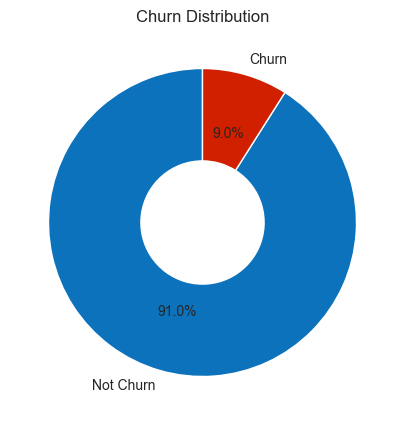

In [21]:
churn_counts = df['is_churn'].value_counts()

labels = ['Not Churn', 'Churn']
sizes = churn_counts.values
colors = ['#0b72bb', '#d02000'] 
plt.figure(figsize=(5,5))
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.6)  
)

plt.title('Churn Distribution')
plt.show()

Tỷ lệ churn chỉ chiếm khoảng 9% tổng số khách hàng, cho thấy đây là bài toán imbalanced classification. Dù số lượng churn không lớn, nhưng đây là nhóm người dùng có giá trị kinh doanh quan trọng vì mất khách hàng thường kéo theo mất doanh thu dài hạn.

# **Customer Profile & Acquisition**

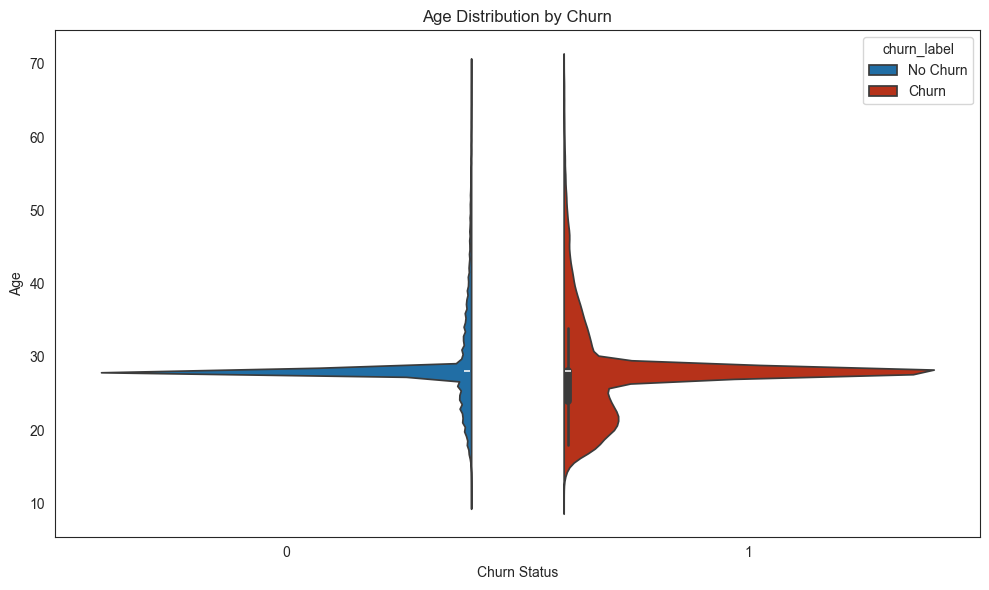

In [22]:
df_clean = df[(df['bd'] >= 10) & (df['bd'] <= 70)].copy()
df_clean['churn_label'] = df_clean['is_churn'].map({0: 'No Churn', 1: 'Churn'})

plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df_clean, 
    x='is_churn', 
    y='bd', 
    hue='churn_label', 
    palette=['#0b72bb', '#d02000'] , 
    split=True
)

plt.title('Age Distribution by Churn')
plt.xlabel('Churn Status')
plt.ylabel('Age')

plt.tight_layout()
plt.show()

Người dùng trẻ có xu hướng ít trung thành hơn.  
Có thể do hành vi nghe nhạc mang tính thử nghiệm, dễ đổi nền tảng hoặc nhạy cảm với trải nghiệm sản phẩm.

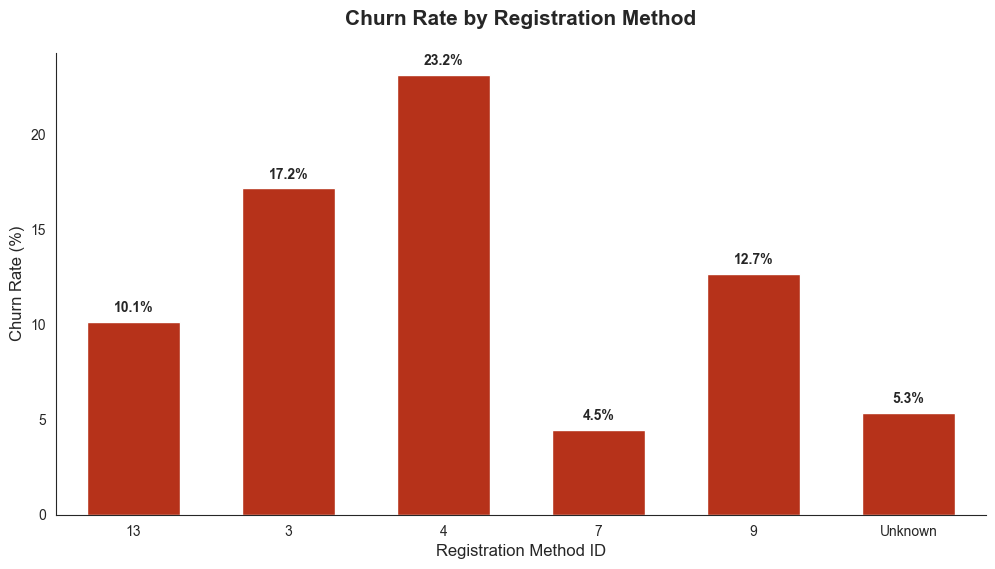

In [23]:
plt.figure(figsize=(12, 6))

reg_churn = df.groupby('registered_via')['is_churn'].mean().reset_index()
reg_churn['is_churn'] *= 100
reg_churn = reg_churn.sort_values('is_churn', ascending=False)

ax = sns.barplot(x='registered_via', y='is_churn', data=reg_churn, color='#d02000', width=0.6)

plt.title('Churn Rate by Registration Method', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xlabel('Registration Method ID', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 5), textcoords='offset points')

sns.despine()
plt.show()

* Acquisition quality khác nhau giữa các channel.
* Một số nguồn đăng ký có thể mang về nhiều “low-intent users” chỉ dùng thử rồi rời đi.
* Registration channel là feature rất mạnh để segment customer quality.  

-> Nên tối ưu marketing budget cho các acquisition channels có retention cao thay vì chỉ tập trung volume user.

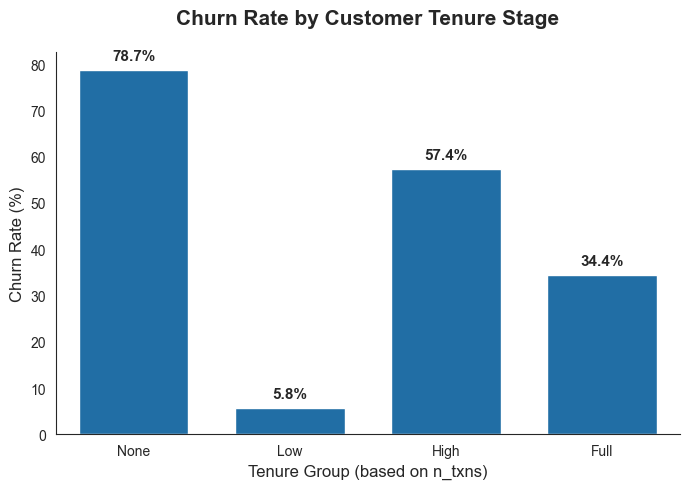

In [24]:
def segment_tenure_by_txns(txns):
    if txns == 0: return 'None'
    elif txns <= 3: return 'Low'
    elif txns <= 9: return 'High'
    else: return 'Full'

df['tenure_group'] = df['n_txns'].apply(segment_tenure_by_txns)
tenure_order = ['None', 'Low', 'High', 'Full']
df['tenure_group'] = pd.Categorical(df['tenure_group'], categories=tenure_order, ordered=True)
tenure_churn = df.groupby('tenure_group', observed=True)['is_churn'].mean().reset_index()
tenure_churn['is_churn'] *= 100

plt.figure(figsize=(7, 5))
ax = sns.barplot(x='tenure_group', y='is_churn', data=tenure_churn, color='#0b72bb', width=0.7)
plt.title('Churn Rate by Customer Tenure Stage', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xlabel('Tenure Group (based on n_txns)', fontsize=12)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}%', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', 
                fontsize=11, fontweight='bold', 
                xytext=(0, 5), 
                textcoords='offset points')
sns.despine()
plt.tight_layout()
plt.show()

- Transaction frequency phản ánh customer commitment.
- Người dùng chưa hình thành subscription habit rất dễ rời bỏ nền tảng.
- Sau khi người dùng đạt đủ số lần thanh toán nhất định, churn giảm đáng kể.  

-> Early lifecycle là giai đoạn quan trọng nhất để giữ chân user.
Cần onboarding flow hoặc retention campaign trong vài transaction đầu tiên.

# **Engagement & Listening Behavior**

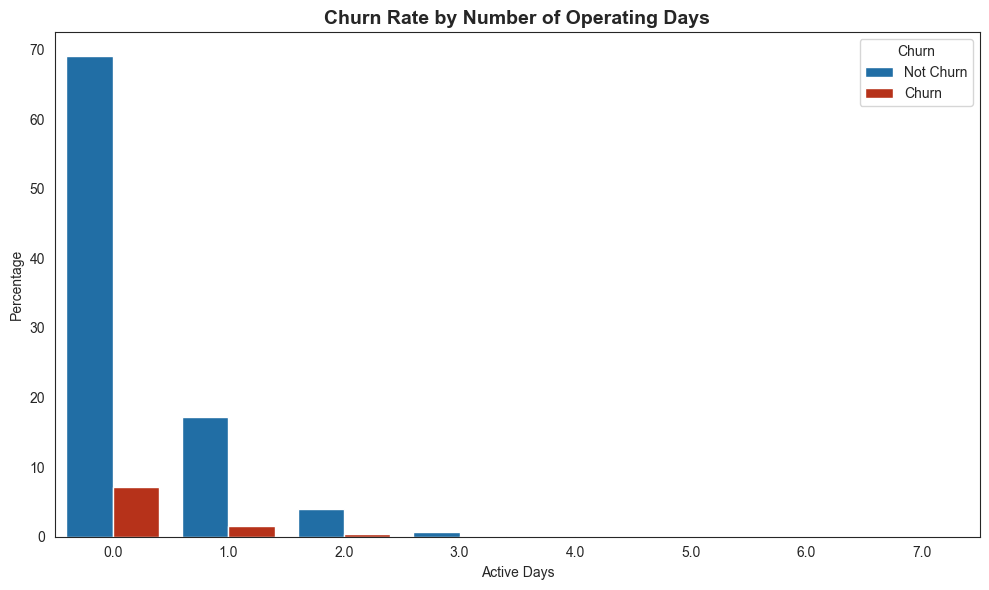

In [25]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='active_days', hue='is_churn', palette=['#0b72bb', '#d02000'] , stat="percent")

plt.title('Churn Rate by Number of Operating Days', fontsize=14, fontweight='bold')
plt.ylabel('Percentage')
plt.xlabel('Active Days')
plt.legend(title='Churn', labels=['Not Churn', 'Churn'])
plt.tight_layout()
plt.show()

- Low activity là tín hiệu sớm của disengagement.
- Chỉ cần giảm tần suất sử dụng trong thời gian ngắn đã có thể dẫn đến churn.

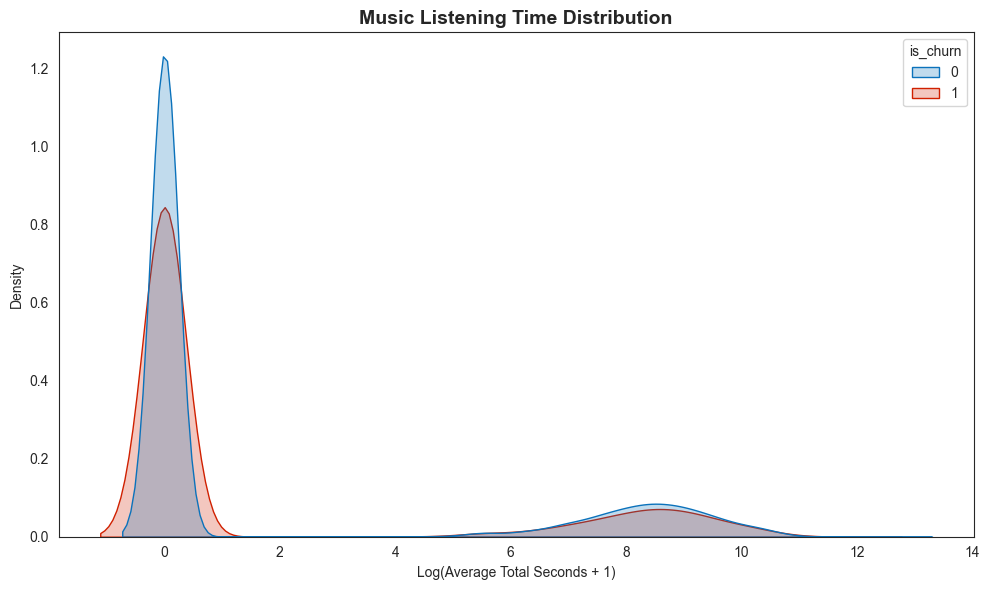

In [26]:
plt.figure(figsize=(10, 6))
log_data = np.log1p(df['total_secs_mean'])

sns.kdeplot(x=log_data, hue=df['is_churn'], fill=True, palette=['#0b72bb', '#d02000'] , common_norm=False)

plt.title('Music Listening Time Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Log(Average Total Seconds + 1)') 
plt.ylabel('Density')
plt.tight_layout()
plt.show()

Nhóm retained users có listening time cao và phân phối ổn định hơn, trong khi churn users tập trung ở mức listening time thấp.

-> 
Listening time phản ánh product stickiness.
User càng dành nhiều thời gian trên nền tảng thì khả năng churn càng thấp.

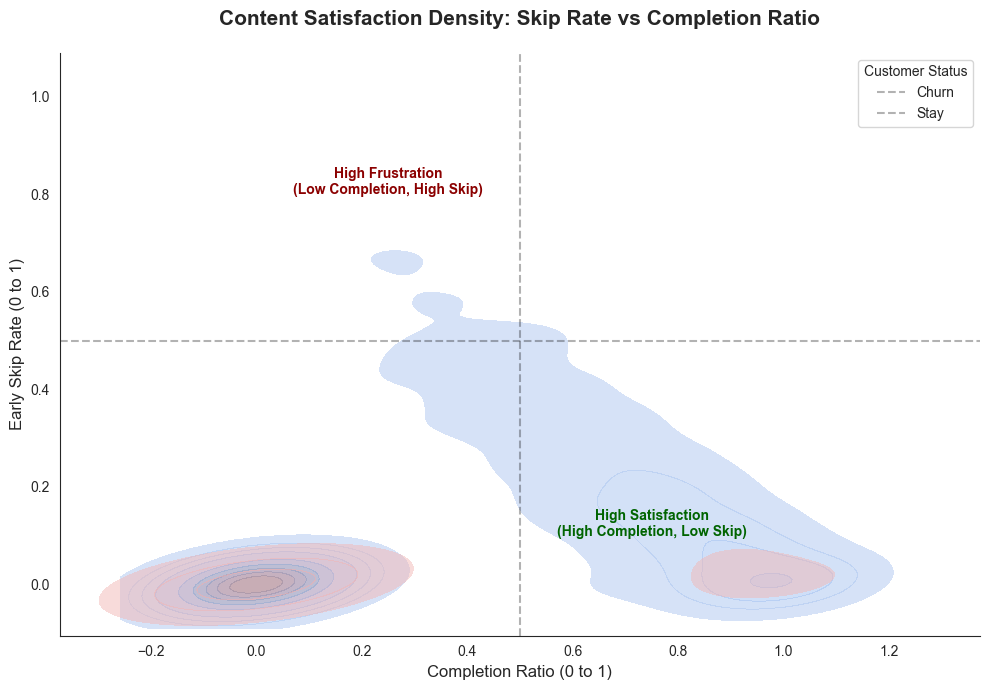

In [27]:
plt.figure(figsize=(10, 7))
df_sample = df.sample(n=min(len(df), 5000), random_state=42)

ax = sns.kdeplot(
    data=df_sample,
    x='completion_ratio',
    y='early_skip_rate',
    hue='is_churn',
    fill=True,           
    thresh=0.05,         
    levels=10,           
    alpha=0.5,           
    palette=['#0b72bb', '#d02000']  
)

plt.axhline(0.5, color='black', linestyle='--', alpha=0.3)
plt.axvline(0.5, color='black', linestyle='--', alpha=0.3)

plt.title('Content Satisfaction Density: Skip Rate vs Completion Ratio', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Completion Ratio (0 to 1)', fontsize=12)
plt.ylabel('Early Skip Rate (0 to 1)', fontsize=12)
plt.legend(title='Customer Status', labels=['Churn', 'Stay'], loc='upper right')
plt.text(0.75, 0.1, 'High Satisfaction\n(High Completion, Low Skip)', 
         fontsize=10, color='darkgreen', fontweight='bold', ha='center')
plt.text(0.25, 0.8, 'High Frustration\n(Low Completion, High Skip)', 
         fontsize=10, color='darkred', fontweight='bold', ha='center')

sns.despine()
plt.tight_layout()
plt.show()

Nhóm churn tập trung ở vùng:completion ratio thấp và early skip rate cao

-> Churn không chỉ đến từ inactivity mà còn từ dissatisfaction.
Người dùng churn có dấu hiệu không tìm được content phù hợp hoặc recommendation chưa tốt.  

-> Recommendation quality ảnh hưởng trực tiếp đến retention.
Skip behavior là tín hiệu cực mạnh cho churn prediction.

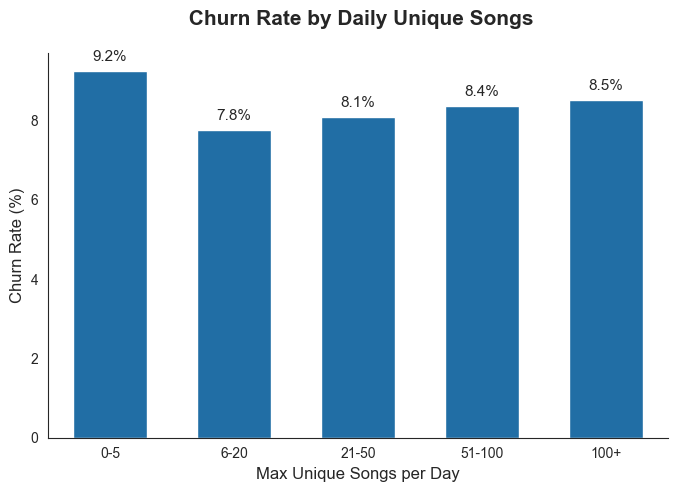

In [28]:
bins = [-1, 5, 20, 50, 100, float('inf')]
labels = ['0-5', '6-20', '21-50', '51-100', '100+']
df['unique_songs_group'] = pd.cut(df['max_unique_songs_per_day'], bins=bins, labels=labels)

plt.figure(figsize=(8, 5))
diversity_churn = df.groupby('unique_songs_group', observed=True)['is_churn'].mean().reset_index()
diversity_churn['is_churn'] *= 100

ax = sns.barplot(x='unique_songs_group', y='is_churn', data=diversity_churn, color='#0b72bb', width=0.6)
plt.title(' Churn Rate by Daily Unique Songs', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xlabel('Max Unique Songs per Day', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11, xytext=(0, 5), textcoords='offset points')

sns.despine()
plt.show()

Người dùng nghe ít bài hát unique mỗi ngày có churn cao hơn.  
-> Người dùng không khám phá content mới thường nhanh chán nền tảng.

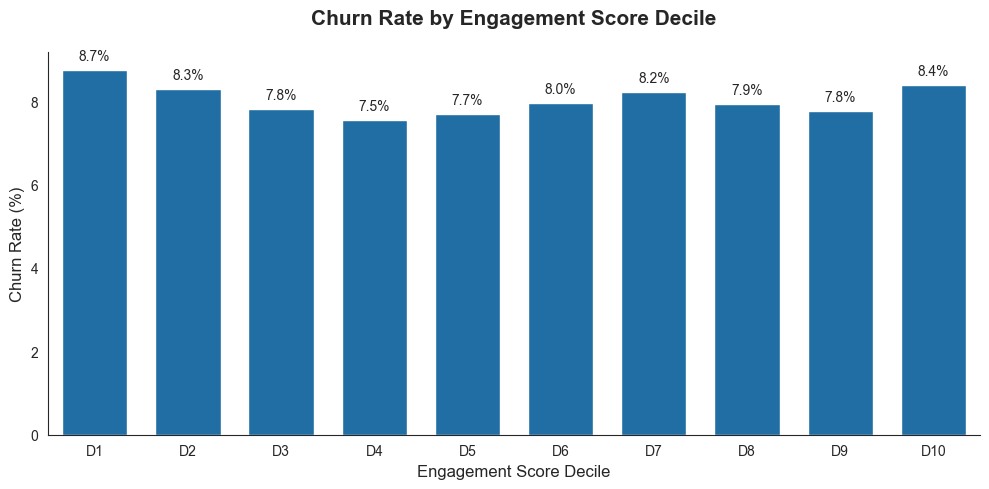

In [29]:
df['engagement_decile'] = pd.qcut(
    df['engagement_score'],
    q=10,
    labels=[f'D{i}' for i in range(1, 11)]
)
engagement_churn = (df.groupby('engagement_decile')['is_churn'].mean().reset_index())
engagement_churn['is_churn'] *= 100

plt.figure(figsize=(10, 5))

ax = sns.barplot(data=engagement_churn,x='engagement_decile',y='is_churn',color='#0b72bb', width=0.7)
plt.title('Churn Rate by Engagement Score Decile',fontsize=15,fontweight='bold',pad=20)
plt.xlabel('Engagement Score Decile', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}%',
                (p.get_x() + p.get_width()/2., height),
                ha='center',
                va='bottom',
                fontsize=10,
                xytext=(0, 5),
                textcoords='offset points')

sns.despine()
plt.tight_layout()
plt.show()

Churn rate giảm mạnh khi engagement score tăng.  
-> 
Engagement score đang capture rất tốt user health.
Có thể dùng như một feature tổng hợp mạnh trong modeling và monitoring.


-> Engagement score phù hợp để xây dựng:
- churn risk segmentation
- retention trigger
- customer health dashboard

# **Subscription & Payment Behavior**

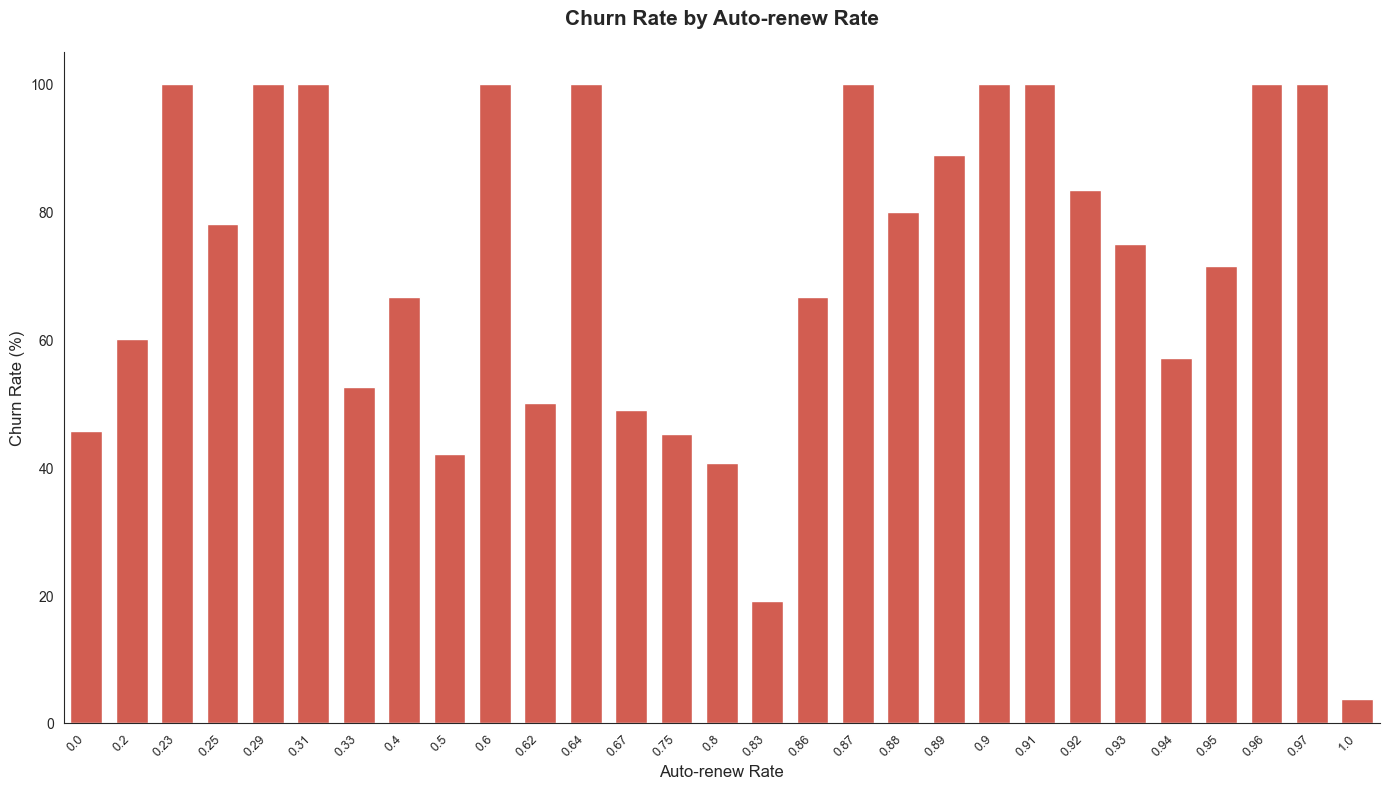

In [30]:
df['auto_renew_rounded'] = df['auto_renew_rate'].round(2)
churn_by_rate = df.groupby('auto_renew_rounded')['is_churn'].mean().reset_index()
churn_by_rate['is_churn'] *= 100
churn_by_rate = churn_by_rate.sort_values('auto_renew_rounded')

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    x='auto_renew_rounded', 
    y='is_churn', 
    data=churn_by_rate,
    width=0.7,
    color='#e74c3c',
    legend = False
)

plt.title('Churn Rate by Auto-renew Rate', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Auto-renew Rate', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)

plt.xticks(rotation=45, ha='right', fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

Tỷ lệ rời bỏ (Churn Rate) biến độngthất thường và không có xu hướng giảm dần ổn định theo tỷ lệ tự động gia hạn. Mặc dù auto_renew_rate=0 giúp giảm thiểu rời bỏ hiệu quả nhất, nhưng việc duy trì ở các mức cận cao (0.9 - 0.97) lại đang cho thấy tỷ lệ rời bỏ cao bất thường, ám chỉ sự thiếu hiệu quả trong việc giữ chân khách hàng hoặc lỗi hệ thống ở các phân khúc này.

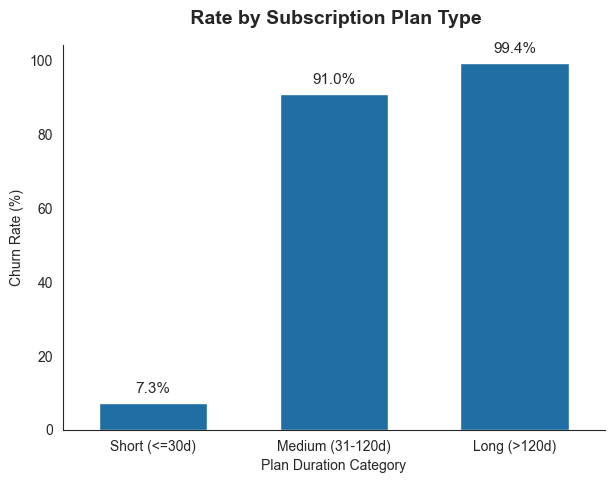

In [31]:
plt.figure(figsize=(7, 5))
df['plan_type'] = pd.cut(df['avg_plan_days'], bins=[-1, 30, 120, float('inf')], 
                         labels=['Short (<=30d)', 'Medium (31-120d)', 'Long (>120d)'])

plan_churn = df.groupby('plan_type')['is_churn'].mean().reset_index()
plan_churn['is_churn'] *= 100

ax2 = sns.barplot(x='plan_type', y='is_churn', data=plan_churn, color='#0b72bb', width=0.6)

plt.title(' Rate by Subscription Plan Type', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Churn Rate (%)')
plt.xlabel('Plan Duration Category')

for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11, xytext=(0, 5), textcoords='offset points')

sns.despine()
plt.show()

Long-term plans tạo switching cost lớn hơn.
Người dùng trả dài hạn thường có mức độ commitment cao hơn.

/var/folders/tt/s_vqbp6j54b6xtqqh5zks7dw0000gn/T/ipykernel_71039/1645362980.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


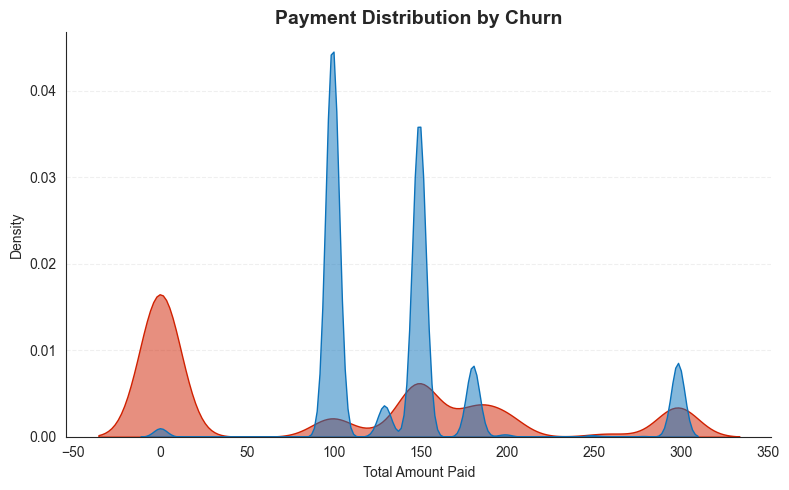

In [33]:
upper = df['total_amount_paid'].quantile(0.95)
df_clean = df[df['total_amount_paid'] <= upper]
df_clean['churn_label'] = df_clean['is_churn'].map({0: 'No Churn', 1: 'Churn'})

plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df_clean,
    x='total_amount_paid',
    hue='churn_label',
    fill=True,
    common_norm=False,
    palette={'No Churn': '#0b72bb', 'Churn': '#d02000'},
    alpha=0.5
)

plt.title('Payment Distribution by Churn', fontsize=14, weight='bold')
plt.xlabel('Total Amount Paid')
plt.ylabel('Density')

plt.legend(frameon=False)
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

High-value users thường được giữ chân tốt hơn.
Người dùng có mức chi tiêu thấp dễ xem nền tảng như dịch vụ “optional”.

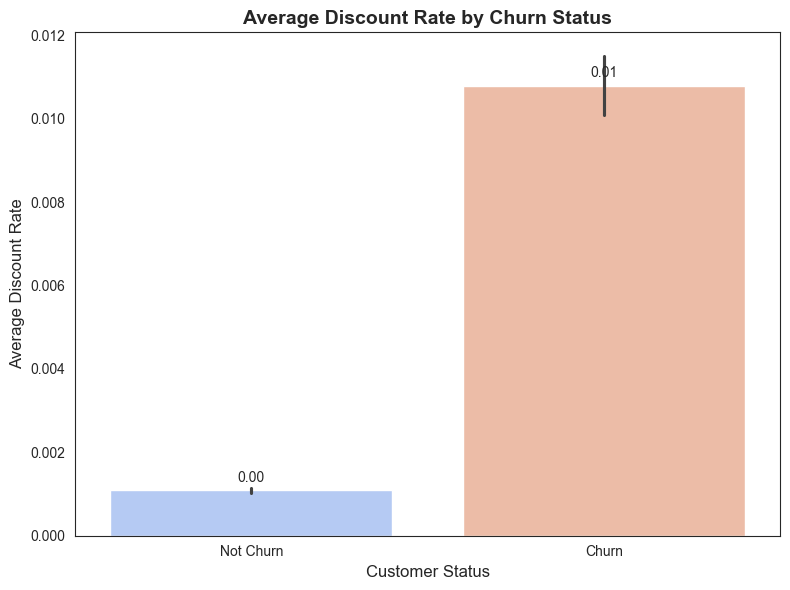

In [34]:
plt.figure(figsize=(8, 6))
ax = sns.barplot(data=df, x='is_churn', y='avg_discount_rate', palette='coolwarm', hue='is_churn', legend=False)

plt.title('Average Discount Rate by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Customer Status', fontsize=12)
plt.ylabel('Average Discount Rate', fontsize=12)

plt.xticks(ticks=[0, 1], labels=['Not Churn', 'Churn'])
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.tight_layout()
plt.show()

User phụ thuộc vào discount thường có loyalty thấp.
Discount có thể giúp acquisition nhưng chưa chắc tạo retention.  
-> 
Over-discounting có thể thu hút low-quality users.

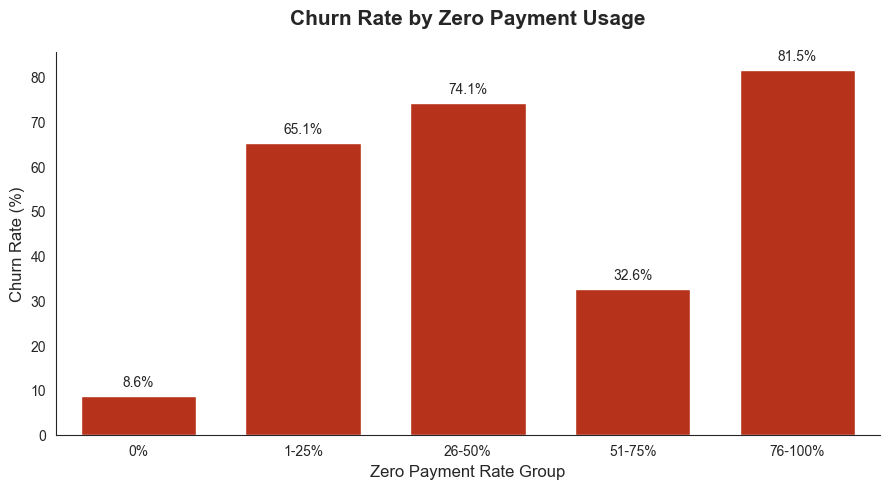

In [35]:
bins = [-0.01, 0, 0.25, 0.5, 0.75, 1.0]

labels = [
    '0%',
    '1-25%',
    '26-50%',
    '51-75%',
    '76-100%'
]
df['zero_paid_group'] = pd.cut(df['zero_paid_rate'],bins=bins,labels=labels)
zero_paid_churn = (
    df.groupby('zero_paid_group', observed=True)['is_churn']
    .mean()
    .reset_index()
)
zero_paid_churn['is_churn'] *= 100

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=zero_paid_churn,x='zero_paid_group',y='is_churn',color='#d02000',width=0.7)

plt.title('Churn Rate by Zero Payment Usage',fontsize=15,fontweight='bold',pad=20)
plt.xlabel('Zero Payment Rate Group', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}%',
                (p.get_x() + p.get_width()/2., height),
                ha='center',
                va='bottom',
                fontsize=10,
                xytext=(0, 5),
                textcoords='offset points')

sns.despine()
plt.tight_layout()
plt.show()

- Người dùng thường xuyên dùng mã giảm giá/ dùng thử miễn phí có mức độ cam kết thấp.
Free behavior kéo dài là tín hiệu rõ ràng của churn risk.  
- Phân khúc 51-75% cần được nghiên cứu thêm để tìm ra lý do giữ chân khách hàng hiệu quả.

# **Feature Relationship**

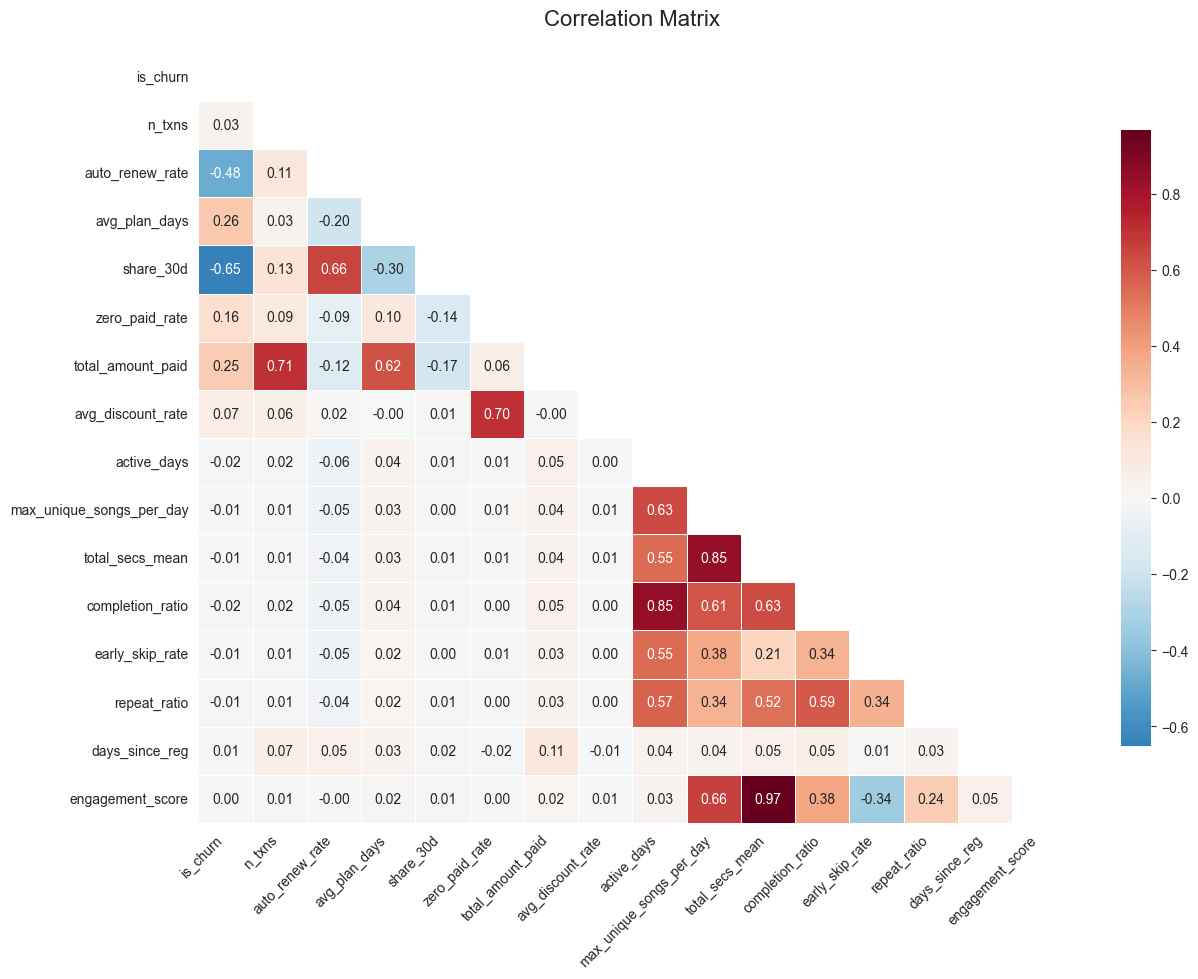

In [36]:
numerical_cols = [
    'is_churn', 'n_txns', 'auto_renew_rate', 'avg_plan_days', 
    'share_30d', 'zero_paid_rate', 'total_amount_paid', 
    'avg_discount_rate', 'active_days', 'max_unique_songs_per_day', 
    'total_secs_mean', 'completion_ratio', 'early_skip_rate', 
    'repeat_ratio', 'days_since_reg', 'engagement_score'
]

corr_matrix = df[numerical_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(14, 10))
heatmap = sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True,           
    fmt=".2f",            
    cmap='RdBu_r',        
    center=0,             
    linewidths=.5,        
    cbar_kws={"shrink": .8}
)

plt.title('Correlation Matrix', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.show()

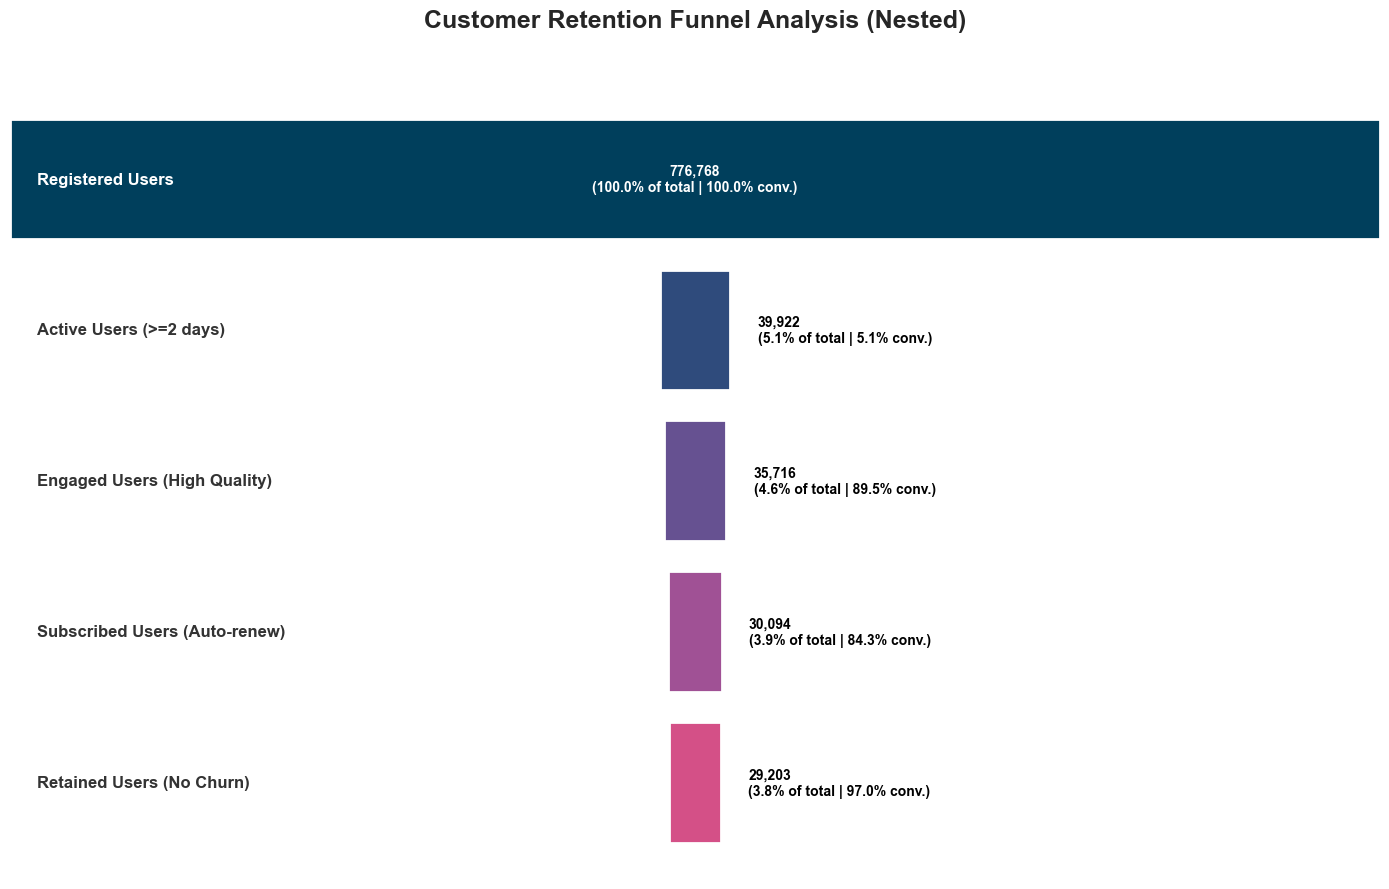

In [38]:
reg_df = df
act_df = reg_df[reg_df['active_days'] >= 2]
eng_df = act_df[(act_df['completion_ratio'] >= 0.5) & (act_df['early_skip_rate'] <= 0.5)]
sub_df = eng_df[eng_df['auto_renew_rate'] > 0]
ret_df = sub_df[sub_df['is_churn'] == 0]

stages = [
    'Registered Users',
    'Active Users (>=2 days)',
    'Engaged Users (High Quality)',
    'Subscribed Users (Auto-renew)',
    'Retained Users (No Churn)'
]

values = [len(reg_df), len(act_df), len(eng_df), len(sub_df), len(ret_df)]

max_val = values[0]
widths = [v / max_val for v in values]
y_pos = range(len(stages))[::-1]  

fig, ax = plt.subplots(figsize=(14, 9))
colors = ['#003f5c', '#2f4b7c', '#665191', '#a05195', '#d45087']

for i, (width, val) in enumerate(zip(widths, values)):
    left = (1 - width) / 2
    stage_color = 'white' if i == 0 else '#333333'
    rect = ax.barh(y_pos[i], width, left=left, color=colors[i], height=0.8, 
                   edgecolor='white', linewidth=2)
    
    ax.text(0.02, y_pos[i], stages[i], ha='left', va='center', 
            fontsize=12, fontweight='bold', color= stage_color)

    pct_total = (val / max_val) * 100
    pct_prev = (val / values[i-1]) * 100 if i > 0 else 100
    
    label_text = f"{val:,}\n({pct_total:.1f}% of total | {pct_prev:.1f}% conv.)"
    text_color = 'white' if width > 0.4 else 'black'
    text_x = 0.5 if width > 0.4 else left + width + 0.02
    ha_type = 'center' if width > 0.4 else 'left'
    
    ax.text(text_x, y_pos[i], label_text, ha=ha_type, va='center', 
            fontsize=10, fontweight='bold', color=text_color)

ax.set_xlim(0, 1)
ax.axis('off')
plt.title('Customer Retention Funnel Analysis (Nested)', fontsize=18, fontweight='bold', pad=40)
plt.tight_layout()
plt.show()

**Overall High-Risk Pattern**

Người dùng mới, hoạt động ít, nghe nhạc ngắn, skip nhiều, ít khám phá content, không bật auto-renew, spending thấp và phụ thuộc vào free/discount plans.